# COMP662 - Tutorial 8
# Large Language Models

Lincoln University, Centre for Geospatial Computing and Technologies.

Generative AI course. This tutorial goes with the *Large Language Models* lecture.

---

### What you will learn
By the end of this tutorial you should be able to:
1. Explain **subword tokenization**, run byte pair encoding by hand, and measure the trade-off
   between vocabulary size and sequence length.
2. Implement the **decoding loop** yourself: greedy, temperature, top-k, top-p (nucleus), and beam
   search, and say what each one does to the next-token distribution.
3. Explain why every LLM is a **causal decoder**, and identify what changed since the original 2017
   transformer (RMSNorm, RoPE, grouped-query attention) inside two real downloaded models.
4. Demonstrate **hallucination** in a real model, and build a cheap quantitative detector for it.
5. Read a real **training loop** and understand gradient accumulation, schedules, and checkpointing,
   then train a very small language model from scratch.
6. Explain the **RLHF objective**, implement the **Bradley-Terry** preference loss, and state the
   **DPO** objective.
7. (Part 2, unguided exercise) Align a small instruct model with **DPO** and measure whether it worked.

### How this tutorial is structured
Part 1 is a guided walk-through (about 1.5 hours): read each explanation, then run the cell under it.
Part 2 is an unguided exercise (about 1 to 1.5 hours) with hints but no worked solution.

Tutorial 3 has the step-by-step guide for running this on a free Kaggle or Colab GPU. Everything here
is CPU-safe by design, so a GPU is a convenience and not a requirement.

### One thing that is different about this tutorial
Every tutorial so far built its models from scratch on data we generated ourselves. This one has to
download **real pretrained models**, because "what does a language model trained on the internet
actually do" is not a question you can answer with a toy. Two small models are pulled from the Hugging
Face Hub the first time you run this (about 400 MB total, cached afterwards). Everything else,
including the corpus we train on, is still generated in this notebook.

---
# Part 1 - Guided walk-through (about 1.5 hours)

## Section 0. Setup and switches

Run this first. If `transformers` is missing, uncomment the install line. On Kaggle and Colab it is
already there.

In [1]:
# If you are on a fresh machine, uncomment the next line once, then restart the kernel.
# !pip install -q "transformers>=4.44" "tokenizers>=0.19"

import os, math, time, random, re                 # stdlib: paths, maths, timing, shuffling, regex
from collections import Counter                   # counts how often each answer repeats (Section 4)
import numpy as np                                # arrays
import torch                                      # PyTorch core
import torch.nn.functional as F                   # softmax, logsigmoid, cross-entropy
import matplotlib.pyplot as plt                   # 2D plotting
try:
    import plotly.graph_objects as go             # optional, only for the one interactive 3D surface
    HAVE_PLOTLY = True
except Exception:
    HAVE_PLOTLY = False                           # notebook falls back to a 2D plot if it is missing

# transformers is new in this tutorial. It is Hugging Face's library for downloading and running
# pretrained models, and it is what lets us work with a real LLM instead of a toy we trained.
import transformers
transformers.logging.set_verbosity_error()        # quieten the load-time notices, they are not errors
# AutoTokenizer/AutoModelForCausalLM read the model's own config and give us the right classes back,
# so the same two lines load any model on the Hub by name.
from transformers import AutoTokenizer, AutoModelForCausalLM
print("PyTorch", torch.__version__, "| transformers", transformers.__version__,
      "| Plotly", "yes" if HAVE_PLOTLY else "no")

/Users/dayoungkim/PycharmProjects/COMP662/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


PyTorch 2.8.0 | transformers 4.57.6 | Plotly yes


In [2]:
# ---- Switches (all in one place) ----------------------------------------
PREFER = "auto"       # "auto" picks CUDA, else Apple MPS, else CPU. Force with "cuda"/"mps"/"cpu".
SEED   = 0            # for reproducible sampling and data generation
SMALL_LM   = "roneneldan/TinyStories-33M"              # a tiny story model, used for decoding demos
INSTRUCT_LM = "HuggingFaceTB/SmolLM2-135M-Instruct"    # a small instruction-following model
N_STORIES  = 6000     # size of the synthetic corpus we build for the tokenizer and the tiny model
TRAIN_ITERS = 300     # training iterations for the from-scratch model in Section 5

def pick_device(prefer="auto"):
    # Return the best available torch.device given the PREFER switch.
    has_cuda = torch.cuda.is_available()                                        # NVIDIA GPU present?
    has_mps  = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()   # Apple GPU?
    if prefer == "cuda" and has_cuda: return torch.device("cuda")               # forced CUDA
    if prefer == "mps"  and has_mps:  return torch.device("mps")                # forced Apple MPS
    if prefer == "cpu":               return torch.device("cpu")                # forced CPU
    if has_cuda: return torch.device("cuda")                                    # auto: CUDA first
    if has_mps:  return torch.device("mps")                                     # then Apple MPS
    return torch.device("cpu")                                                  # CPU always works

device = pick_device(PREFER)                       # the device we will run models on
torch.manual_seed(SEED); random.seed(SEED)         # make this notebook reproducible
np.random.seed(SEED)                               # numpy has its own generator to seed
print("Using device:", device)

Using device: mps


In [35]:
# Load the small story model. First run downloads it (about 130 MB), later runs read the local cache.
t0 = time.time()                                                     # time the load, for reference
tok_small = AutoTokenizer.from_pretrained(SMALL_LM)                  # its tokenizer
lm_small = AutoModelForCausalLM.from_pretrained(SMALL_LM).to(device).eval()   # its weights
n_params = sum(p.numel() for p in lm_small.parameters())             # count every parameter
print(f"loaded {SMALL_LM} in {time.time()-t0:.1f}s")
print(f"parameters: {n_params/1e6:.1f}M  (the name says 33M, which counts only the non-embedding weights)")

# Generate one sample straight away, so you see this thing work inside the first five minutes.
enc = tok_small("Once upon a time, in a valley below the mountains,", return_tensors="pt").to(device)
with torch.no_grad():                                                # no gradients needed to generate
    out = lm_small.generate(**enc, max_new_tokens=40, do_sample=True, temperature=0.8,
                            top_p=0.95, pad_token_id=tok_small.eos_token_id)
print("\nsample:", tok_small.decode(out[0], skip_special_tokens=True))

loaded roneneldan/TinyStories-33M in 3.0s
parameters: 68.5M  (the name says 33M, which counts only the non-embedding weights)

sample: Once upon a time, in a valley below the mountains, there lived a kind bunny named Bobo. Bobo loved to play with his friends, the birds, and the squirrels. They played all day in the sun and in the cool valley.



## Section 1. Tokenization: how text becomes numbers

A language model never sees characters or words. It sees **token ids**. A tokenizer is the piece that
decides how a string is cut up, and that decision has consequences all the way through the system: it
sets the vocabulary size, the length of every sequence, and therefore the cost of every forward pass.

Modern models use **subword** tokenization, usually **byte pair encoding (BPE)**. The idea is short:
start with characters, then repeatedly find the most frequent adjacent pair and merge it into a new
symbol. Common words end up as single tokens, rare words get split into pieces, and nothing is ever
out of vocabulary because you can always fall back to characters.

Let us look at what a real tokenizer does first, then build one.

In [4]:
sentence = "The hydrologist surveyed the waterlogged estuary near Frostthwaite."
ids = tok_small(sentence)["input_ids"]                          # encode to token ids
pieces = [tok_small.decode([i]) for i in ids]                   # decode each id on its own, to see it

print("sentence   :", sentence)
print("word count :", len(sentence.split()))                    # words, by whitespace
print("token count:", len(ids), "  <- not the same number")     # tokens, by the tokenizer
print("\nid -> piece")
for i, p in zip(ids, pieces):                                   # show the split explicitly
    print(f"  {i:>6}  {p!r}")
print("\nround trip:", tok_small.decode(ids))                   # decoding gets the string back

sentence   : The hydrologist surveyed the waterlogged estuary near Frostthwaite.
word count : 8
token count: 17   <- not the same number

id -> piece
     464  'The'
    7409  ' hyd'
   40329  'rolog'
     396  'ist'
   20840  ' surveyed'
     262  ' the'
    1660  ' water'
    6404  'log'
    2004  'ged'
    1556  ' est'
    2838  'uary'
    1474  ' near'
   15122  ' Frost'
     400  'th'
   10247  'wa'
     578  'ite'
      13  '.'

round trip: The hydrologist surveyed the waterlogged estuary near Frostthwaite.


### Byte pair encoding by hand

Before using a library, run the merge loop yourself on a five-word corpus. The point is to watch the
vocabulary grow one merge at a time, so the library version has nothing mysterious left in it.

In [5]:
def bpe_by_hand(words, n_merges):
    # words: a dict of word -> count. Returns the list of merges learned, printing each one.
    # Each word is held as a tuple of symbols; we start from single characters.
    vocab = {tuple(w) + ("</w>",): c for w, c in words.items()}      # </w> marks the end of a word
    merges = []                                                      # the merge rules, in order
    for step in range(n_merges):
        pairs = Counter()                                            # count every adjacent symbol pair
        for symbols, count in vocab.items():                         # for each word form
            for i in range(len(symbols) - 1):                        # for each adjacent position
                pairs[(symbols[i], symbols[i + 1])] += count         # weight by how often the word occurs
        if not pairs: break                                          # nothing left to merge
        best = max(pairs, key=pairs.get)                             # the most frequent pair wins
        merges.append(best)                                          # record the rule
        merged = "".join(best)                                       # the new symbol
        new_vocab = {}                                               # rebuild the vocabulary with it
        for symbols, count in vocab.items():
            out, i = [], 0                                           # scan left to right
            while i < len(symbols):
                if i < len(symbols) - 1 and (symbols[i], symbols[i + 1]) == best:
                    out.append(merged); i += 2                       # apply the merge
                else:
                    out.append(symbols[i]); i += 1                   # copy the symbol through
            new_vocab[tuple(out)] = count
        vocab = new_vocab
        print(f"merge {step+1}: {best[0]!r} + {best[1]!r} -> {merged!r}   (seen {pairs[best]} times)")
    return merges, vocab

# A deliberately repetitive mini corpus, so the merges are easy to follow.
mini = {"low": 5, "lower": 2, "lowest": 1, "slow": 3, "slowest": 1}
print("corpus:", mini, "\n")
_merges, _final = bpe_by_hand(mini, n_merges=8)
print("\nfinal word forms:")
for symbols, count in _final.items():                                # how each word is now split
    print(f"  {''.join(symbols):>16}  ->  {list(symbols)}")

corpus: {'low': 5, 'lower': 2, 'lowest': 1, 'slow': 3, 'slowest': 1} 

merge 1: 'l' + 'o' -> 'lo'   (seen 12 times)
merge 2: 'lo' + 'w' -> 'low'   (seen 12 times)
merge 3: 'low' + '</w>' -> 'low</w>'   (seen 8 times)
merge 4: 'low' + 'e' -> 'lowe'   (seen 4 times)
merge 5: 's' + 'low</w>' -> 'slow</w>'   (seen 3 times)
merge 6: 'lowe' + 'r' -> 'lower'   (seen 2 times)
merge 7: 'lower' + '</w>' -> 'lower</w>'   (seen 2 times)
merge 8: 'lowe' + 's' -> 'lowes'   (seen 2 times)

final word forms:
           low</w>  ->  ['low</w>']
         lower</w>  ->  ['lower</w>']
        lowest</w>  ->  ['lowes', 't', '</w>']
          slow</w>  ->  ['slow</w>']
       slowest</w>  ->  ['s', 'lowes', 't', '</w>']


### A corpus to train a tokenizer on

We need text. Rather than download a corpus, we generate one: short field-report style paragraphs
about land and weather, with **invented place names** built from syllable parts. Those invented names
matter. They give the corpus a few hundred distinct proper nouns, which is exactly the situation
subword tokenization exists to handle, and it lets us see a real vocabulary-size trade-off in a corpus
we control completely.

In [6]:
PRE = ["black", "white", "grey", "red", "stone", "iron", "fern", "elder", "mist", "frost", "thorn",
       "ash", "bright", "deep", "long", "cold", "green", "salt", "wind", "raven", "alder", "birch",
       "crag", "dun", "glen", "holl", "marsh", "pine", "rook", "sedge"]          # name first halves
SUF = ["ridge", "hollow", "moor", "fell", "dale", "mere", "combe", "brook", "cliff", "heath",
       "marsh", "scar", "tarn", "wold", "bourne", "crag", "haven", "reach", "shaw", "thwaite"]
PLACE_NAMES = sorted({p.capitalize() + s for p in PRE for s in SUF})             # 600 invented names

# Word banks for the rest of the sentence. Each list fills one slot in the template below.
ADJ  = ["rocky", "steep", "green", "dry", "wet", "rich", "sandy", "calm", "stormy", "misty", "sunny",
        "cold", "windy", "frozen", "terraced", "eroded", "fertile", "barren"]
PLACE = ["mountain", "farmland", "coast", "valley", "river", "forest", "desert", "glacier", "island",
         "wetland", "plateau", "estuary", "ridge", "basin"]
WEATHER = ["heavy rain", "strong wind", "thick fog", "bright sun", "cool breeze", "deep snow",
           "light drizzle", "dry heat", "late frost"]
CROP = ["wheat", "corn", "rice", "cotton", "barley", "soy", "olives", "grapes", "millet", "rye"]
WHO  = ["the farmer", "the ranger", "the surveyor", "the geologist", "the shepherd", "the botanist"]
VERB = ["walked across", "surveyed", "mapped", "photographed", "measured", "sketched", "inspected"]

def make_report(rng):
    # One short field report. Every filler is drawn at random, so reports rarely repeat exactly.
    n1, n2 = rng.choice(PLACE_NAMES, 2, replace=False)                # two different invented places
    a, p, w = rng.choice(ADJ), rng.choice(PLACE), rng.choice(WEATHER)  # adjective, landform, weather
    c, who, v = rng.choice(CROP), rng.choice(WHO), rng.choice(VERB)    # crop, person, verb
    year = rng.integers(1890, 2030)                                   # a year, to add number tokens
    return (f"in {year} {who} {v} the {a} {p} near {n1} . "
            f"there was {w} over {n2} that morning . "
            f"the soil below {n1} was {rng.choice(ADJ)} and the {c} was already tall . "
            f"{who} recorded that {n2} and the {p} were changing .")

gen = np.random.default_rng(SEED)                                     # seeded, so the corpus repeats
corpus = [make_report(gen) for _ in range(N_STORIES)]                 # build every report up front
word_types = {w for s in corpus for w in s.split()}                   # how many distinct words we made
print(f"reports: {len(corpus)}  |  characters: {sum(map(len, corpus)):,}")
print(f"distinct word types: {len(word_types)}  |  invented place names: {len(PLACE_NAMES)}")
print("\nexample:\n", corpus[0])

reports: 6000  |  characters: 1,509,128
distinct word types: 830  |  invented place names: 600

example:
 in 2003 the farmer surveyed the wet river near Sedgehollow . there was heavy rain over Mistcliff that morning . the soil below Sedgehollow was cold and the wheat was already tall . the farmer recorded that Mistcliff and the river were changing .


### Training real BPE tokenizers at different vocabulary sizes

Now the trade-off. A **small** vocabulary means every word gets chopped into many pieces, so sequences
are long and each forward pass costs more. A **large** vocabulary means short sequences, but a bigger
embedding table and more rare tokens that the model sees too few times to learn well.

This is the same shape of problem as the bias-variance trade-off: neither extreme is right, and the
useful part is knowing which way you are erring.

In [7]:
# tokenizers is Hugging Face's tokenizer library, and it ships with transformers, so there is
# nothing extra to install. We use it here to TRAIN our own tokenizers rather than load one.
from tokenizers import Tokenizer, models, trainers, pre_tokenizers

def train_bpe(vocab_size):
    # Train a BPE tokenizer on our corpus at the requested vocabulary size.
    tk = Tokenizer(models.BPE(unk_token="<unk>"))                    # an empty BPE model
    tk.pre_tokenizer = pre_tokenizers.Whitespace()                   # split on whitespace first
    trainer = trainers.BpeTrainer(vocab_size=vocab_size,             # the target vocabulary size
                                  special_tokens=["<unk>", "<pad>", "<eos>"],
                                  show_progress=False)               # keep the output quiet
    tk.train_from_iterator(corpus, trainer)                          # learn the merges
    return tk

sizes = [256, 512, 1024, 2048, 8192]                                 # the sweep
trained = {}                                                         # keep each tokenizer for later
rows = []                                                            # table rows to print and plot
for vs in sizes:
    tk = train_bpe(vs); trained[vs] = tk                             # train and store
    lengths = [len(tk.encode(s).ids) for s in corpus[:500]]          # tokens per report, on a sample
    chars_per_token = np.mean([len(s) for s in corpus[:500]]) / np.mean(lengths)
    rows.append((vs, tk.get_vocab_size(), np.mean(lengths), chars_per_token))

print(f"{'asked for':>10} {'actual':>8} {'mean tokens/report':>20} {'chars per token':>17}")
for vs, actual, mean_len, cpt in rows:                               # print the trade-off table
    print(f"{vs:>10} {actual:>8} {mean_len:>20.1f} {cpt:>17.2f}")
print("\nNote where 'actual' stops growing. Our corpus only contains so many distinct pieces, so past")
print("that point asking for a bigger vocabulary gets you nothing. Real corpora saturate too, just")
print("much later.")

 asked for   actual   mean tokens/report   chars per token
       256      256                 67.5              3.73
       512      512                 48.5              5.18
      1024     1024                 45.0              5.59
      2048     1176                 44.1              5.70
      8192     1176                 44.1              5.70

Note where 'actual' stops growing. Our corpus only contains so many distinct pieces, so past
that point asking for a bigger vocabulary gets you nothing. Real corpora saturate too, just
much later.


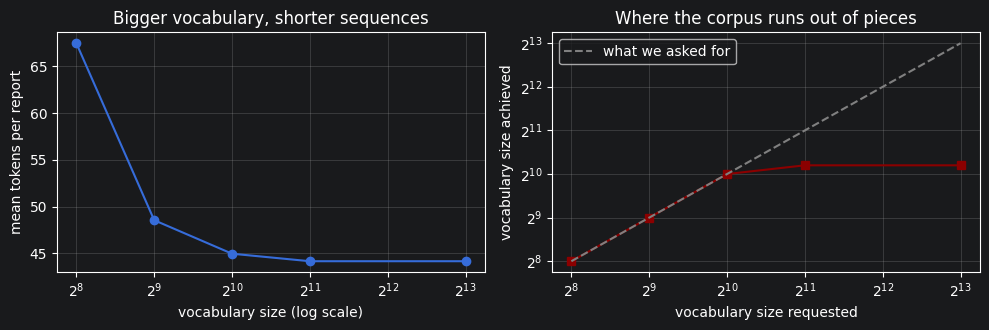

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))                      # two panels side by side
ax[0].plot([r[0] for r in rows], [r[2] for r in rows], "o-")         # sequence length against vocab
ax[0].set_xscale("log", base=2); ax[0].set_xlabel("vocabulary size (log scale)")   # sizes double
ax[0].set_ylabel("mean tokens per report"); ax[0].set_title("Bigger vocabulary, shorter sequences")
ax[0].grid(True, alpha=0.3)                                          # a light grid helps reading
ax[1].plot([r[0] for r in rows], [r[1] for r in rows], "s-", color="darkred")   # what we actually got
ax[1].plot([r[0] for r in rows], [r[0] for r in rows], "--", color="grey", label="what we asked for")
ax[1].set_xscale("log", base=2); ax[1].set_yscale("log", base=2)     # log on both, so equal = a line
ax[1].set_xlabel("vocabulary size requested"); ax[1].set_ylabel("vocabulary size achieved")
ax[1].set_title("Where the corpus runs out of pieces"); ax[1].legend(); ax[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [9]:
# The same sentence through three different vocabularies. This is the trade-off made concrete.
probe = "the eroded plateau near Frostthwaite had late frost"      # note: 'had' is NOT in our corpus
for vs in [256, 1024, 8192]:                                         # small, medium, saturated
    print(f"vocab {vs:>5}: {trained[vs].encode(probe).tokens}")      # .tokens shows the pieces, not ids
print("\nTwo things to notice.")
print("1. 'Frostthwaite' is one token in the larger vocabularies and several pieces in the smallest.")
print("2. 'had' splits into characters everywhere, because our corpus never uses that word. That is")
print("   subword tokenization doing its job: an unseen word degrades into pieces instead of failing.")

vocab   256: ['the', 'er', 'o', 'ded', 'plateau', 'near', 'F', 'rost', 'thwaite', 'h', 'a', 'd', 'late', 'f', 'rost']
vocab  1024: ['the', 'eroded', 'plateau', 'near', 'Frostthwaite', 'h', 'a', 'd', 'late', 'frost']
vocab  8192: ['the', 'eroded', 'plateau', 'near', 'Frostthwaite', 'h', 'a', 'd', 'late', 'frost']

Two things to notice.
1. 'Frostthwaite' is one token in the larger vocabularies and several pieces in the smallest.
2. 'had' splits into characters everywhere, because our corpus never uses that word. That is
   subword tokenization doing its job: an unseen word degrades into pieces instead of failing.


### What happens if the tokenizer and the model disagree

The tokenizer is not a detachable accessory. Token id 4023 means whatever the model learned it to
mean during training, and a different tokenizer assigns that id to a different piece of text. Feeding
a model ids from the wrong tokenizer is not a subtle degradation, it is nonsense in and nonsense out.
This is worth seeing once so you recognise it when it happens to you.

In [10]:
prompt_text = "Once upon a time, in a valley below the mountains,"    # the same prompt as Section 0
right_ids = tok_small(prompt_text, return_tensors="pt")["input_ids"]  # ids from the CORRECT tokenizer

tok_other = AutoTokenizer.from_pretrained(INSTRUCT_LM)                # a DIFFERENT model's tokenizer
wrong_ids = tok_other(prompt_text, return_tensors="pt")["input_ids"]  # ids from the WRONG tokenizer

print("same text, two tokenizers:")
print("  correct tokenizer ids:", right_ids[0, :8].tolist())          # what our model expects
print("  wrong tokenizer ids  :", wrong_ids[0, :8].tolist())          # what we are about to feed it
# Its vocabulary is smaller, so every id is still a legal input. Nothing crashes. That is the trap:
# the failure is silent, and you only notice it in the output.
print(f"  wrong vocab size {tok_other.vocab_size} < model vocab size {lm_small.config.vocab_size},"
      " so every id is 'valid'")
print("\nwhat the model actually reads when given the wrong ids:")
print(" ", repr(tok_small.decode(wrong_ids[0])))                      # decode them as the model would

for label, ids_in in [("correct tokenizer", right_ids), ("wrong tokenizer", wrong_ids)]:
    with torch.no_grad():                                             # generate greedily, no sampling
        out = lm_small.generate(input_ids=ids_in.to(device), max_new_tokens=25, do_sample=False,
                                pad_token_id=tok_small.eos_token_id)
    # Decode with the model's OWN tokenizer, which is what the model effectively "said".
    print(f"\n{label}:\n  {tok_small.decode(out[0], skip_special_tokens=True)!r}")

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/655 [00:00<?, ?B/s]

same text, two tokenizers:
  correct tokenizer ids: [7454, 2402, 257, 640, 11, 287, 257, 19272]
  wrong tokenizer ids  : [6403, 1980, 253, 655, 28, 281, 253, 12322]
  wrong vocab size 49152 < model vocab size 50257, so every id is 'valid'

what the model actually reads when given the wrong ids:
  ' universityirc� just= an�Take Stere hyper='

correct tokenizer:
  "Once upon a time, in a valley below the mountains, there lived a little girl named Lily. She loved to play with her toys and her friends. One day, Lily's mom"

wrong tokenizer:
  ' universityirc� just= an�Take Stere hyper=heeheeheeheeheeheeheeheeheeheeheehee-olding.\n'


## Section 2. Decoding: turning a distribution into text

A language model does one thing: given a sequence of tokens, it produces a score for every token in
the vocabulary as the possible next token. Softmax those scores and you have a probability
distribution. **Decoding** is the separate question of how you turn that distribution into an actual
choice, repeatedly, to build a sequence.

This matters more than beginners expect. The same model with the same weights and the same prompt can
be repetitive, fluent, or incoherent depending only on the decoding strategy. None of these strategies
change the model. They change what you do with its output.

We will implement the loop ourselves rather than calling `generate`, because everything interesting
lives in four lines of it.

In [11]:
# Look at one real next-token distribution before choosing anything from it.
ctx = tok_small("The ranger walked across the frozen", return_tensors="pt").to(device)
with torch.no_grad():                                                 # no gradients, we are not training
    logits = lm_small(**ctx).logits[0, -1]                            # [0] = first (only) sequence,
                                                                      # [-1] = last position = next token
probs = torch.softmax(logits, dim=-1)                                 # turn scores into probabilities
top = torch.topk(probs, 10)                                           # the ten most likely tokens

print("context:", tok_small.decode(ctx["input_ids"][0]))
print(f"\nvocabulary size: {probs.numel()}   (a distribution over all of these, every single step)")
print(f"\n{'rank':>4} {'token':>14} {'probability':>12}")
for r, (p, i) in enumerate(zip(top.values.tolist(), top.indices.tolist())):
    print(f"{r+1:>4} {tok_small.decode([i])!r:>14} {p:>12.4f}")
print(f"\nthese ten tokens hold {top.values.sum().item():.3f} of all the probability mass")

context: The ranger walked across the frozen

vocabulary size: 50257   (a distribution over all of these, every single step)

rank          token  probability
   1        ' pond'       0.3628
   2        ' lake'       0.2732
   3       ' river'       0.0704
   4      ' ground'       0.0303
   5       ' field'       0.0218
   6       ' water'       0.0195
   7         ' ice'       0.0148
   8       ' swamp'       0.0117
   9           ' p'       0.0114
  10        ' land'       0.0104

these ten tokens hold 0.826 of all the probability mass


### The five strategies, as transforms of that distribution

Each strategy is a small edit to the distribution above, then a draw from it.

| Strategy | What it does to the distribution |
|---|---|
| **Greedy** | ignore it, take the single highest-probability token |
| **Temperature** | divide the logits by `T` before softmax: `T<1` sharpens, `T>1` flattens |
| **Top-k** | keep the `k` most likely tokens, zero the rest, renormalise |
| **Top-p (nucleus)** | sort descending, keep the smallest set whose probabilities sum past `p`, renormalise |
| **Beam search** | do not sample at all, keep the `b` best partial sequences and extend them all |

The first four are one function with four branches. Beam search is different enough to write
separately, because it tracks several sequences at once.

In [12]:
def transform_logits(logits, strategy, temperature=1.0, k=50, p=0.9):
    # Apply one decoding strategy to a 1D tensor of next-token logits, returning probabilities.
    if strategy == "greedy":                                          # greedy needs no distribution
        out = torch.zeros_like(logits)                                 # all-zero probabilities...
        out[logits.argmax()] = 1.0                                     # ...except a 1 on the best token
        return out
    logits = logits / temperature                                      # temperature scales the scores
    if strategy == "top_k":
        kth = torch.topk(logits, k).values[-1]                         # the k-th largest score
        logits = logits.masked_fill(logits < kth, float("-inf"))       # drop everything below it
    elif strategy == "top_p":
        srt, idx = torch.sort(logits, descending=True)                 # SORT DESCENDING first, this is
        cum = torch.softmax(srt, dim=-1).cumsum(dim=-1)                # the step that makes it nucleus
        cut = int((cum < p).sum().item()) + 1                          # smallest set reaching mass p
        keep = idx[:cut]                                               # the ids we are allowed to use
        mask = torch.full_like(logits, float("-inf"))                  # start by banning everything
        mask[keep] = logits[keep]                                      # then allow the nucleus back in
        logits = mask
    return torch.softmax(logits, dim=-1)                               # renormalise over what is left

# Show what each transform does to the SAME distribution, at one step.
print(f"{'strategy':>22} {'tokens with p>0':>16} {'top token':>14} {'its p':>8}")
for name, kw in [("greedy", {}), ("temperature 0.7", {"temperature": 0.7}),
                 ("temperature 1.5", {"temperature": 1.5}), ("top_k (k=10)", {"k": 10}),
                 ("top_p (p=0.9)", {"p": 0.9})]:
    strat = "greedy" if name == "greedy" else ("top_k" if "top_k" in name else
            ("top_p" if "top_p" in name else "temperature"))
    q = transform_logits(logits, strat, **kw)                          # transformed distribution
    alive = int((q > 0).sum().item())                                  # how many tokens survive
    best = q.argmax().item()                                           # its most likely token
    print(f"{name:>22} {alive:>16} {tok_small.decode([best])!r:>14} {q[best].item():>8.3f}")

              strategy  tokens with p>0      top token    its p
                greedy                1        ' pond'    1.000
       temperature 0.7            50257        ' pond'    0.525
       temperature 1.5            50257        ' pond'    0.126
          top_k (k=10)               10        ' pond'    0.439
         top_p (p=0.9)               28        ' pond'    0.403


In [13]:
def generate_manually(model, tokenizer, prompt, strategy="top_p", max_new_tokens=40,
                      temperature=1.0, k=50, p=0.9, seed=None):
    # The whole decoding loop, written out. This is what model.generate does underneath.
    if seed is not None: torch.manual_seed(seed)                       # reproducible sampling
    ids = tokenizer(prompt, return_tensors="pt")["input_ids"].to(device)   # encode the prompt
    for _ in range(max_new_tokens):                                    # one token per iteration
        with torch.no_grad():                                          # inference only
            step_logits = model(input_ids=ids).logits[0, -1]           # scores for the next token
        q = transform_logits(step_logits, strategy, temperature, k, p) # apply the strategy
        nxt = torch.multinomial(q, num_samples=1)                      # draw one token from it
        ids = torch.cat([ids, nxt[None, :]], dim=1)                    # append and go round again
        if nxt.item() == tokenizer.eos_token_id: break                 # stop if the model says stop
    return tokenizer.decode(ids[0], skip_special_tokens=True)

PROMPT = "Once upon a time, in a valley below the mountains,"          # one fixed prompt throughout
for strat, kw in [("greedy", {}), ("temperature", {"temperature": 1.0}),
                  ("top_k", {"k": 10}), ("top_p", {"p": 0.9})]:
    text = generate_manually(lm_small, tok_small, PROMPT, strat, seed=SEED, **kw)
    print(f"\n--- {strat} {kw} ---\n{text}")


--- greedy {} ---
Once upon a time, in a valley below the mountains, there lived a little girl named Lily. She loved to play with her toys and her friends. One day, Lily's mom asked her to help her with the groceries. Lily was happy to help and

--- temperature {'temperature': 1.0} ---
Once upon a time, in a valley below the mountains, lived two best friends: Emily and John. 
One day, they decided to go on an adventure. They took their bicycles and went to a big city. 
When they arrived, they

--- top_k {'k': 10} ---
Once upon a time, in a valley below the mountains, lived two best friends: Jack and Jill. 
One day, they decided to go on an adventure. They took their bicycles and went to a big city. 
Jack said to Jill,

--- top_p {'p': 0.9} ---
Once upon a time, in a valley below the mountains, lived two best friends: Emily and John. 
One day, they decided to go on an adventure. They took their bicycles and went to a big city. 
When they arrived, they


### Temperature, measured rather than described

"Lower temperature is less random" is the usual phrasing, and it is true but useless: you cannot act
on it. Below we measure two quantities per setting, so randomness becomes a number.

- **Mean token entropy**: the average uncertainty, in bits, of the distribution we actually sampled
  from at each step. Low entropy means the model was confident.
- **Distinct token ratio**: unique tokens divided by total tokens in the output. Low values mean the
  text repeats itself.

Watch them move in opposite directions, and watch the text fall apart at the top of the range.


--- temperature 0.1 | mean entropy 0.03 bits | distinct ratio 0.80 ---
there lived a little girl named Lily. She loved to play with her toys and her friends. One day, Lily's mom told her that they were going to have a picnic in the valley. Lily

--- temperature 0.7 | mean entropy 1.02 bits | distinct ratio 0.80 ---
there was a mighty king. He could run fast and strong, which made everyone happy. One day, the king was running so fast that he didn't see a rock in his way. He tri

--- temperature 1.0 | mean entropy 2.29 bits | distinct ratio 0.78 ---
lived two best friends: Emily and John. 
One day, they decided to go on an adventure. They took their bicycles and went to a big city. 
When they arrived, they

--- temperature 1.5 | mean entropy 5.12 bits | distinct ratio 0.93 ---
lived two best friends: Emily and John. 
One morning, they decided to go for geographyayaults around the wonders of urged stage visiting every mountain. 
mess how far away bushwork

--- temperature 2.0 | mean entr

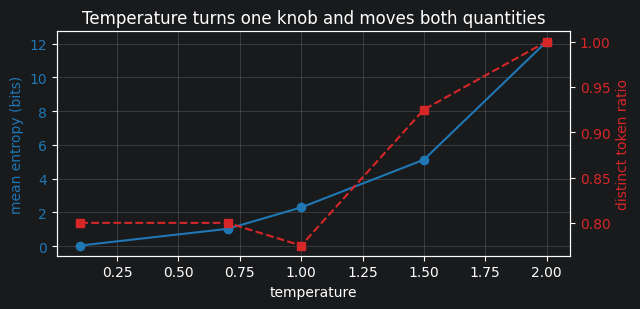

In [14]:
def decode_with_stats(temperature, max_new_tokens=40, seed=SEED):
    # Generate at one temperature, and record the entropy of every distribution we sample from.
    torch.manual_seed(seed)                                            # same seed for every setting
    ids = tok_small(PROMPT, return_tensors="pt")["input_ids"].to(device)
    entropies = []                                                     # one entropy per step
    for _ in range(max_new_tokens):
        with torch.no_grad():
            step_logits = lm_small(input_ids=ids).logits[0, -1]         # next-token scores
        q = torch.softmax(step_logits / temperature, dim=-1)           # pure temperature sampling
        ent = -(q * torch.log2(q.clamp_min(1e-12))).sum().item()       # Shannon entropy, in bits
        entropies.append(ent)                                          # clamp_min avoids log(0)
        ids = torch.cat([ids, torch.multinomial(q, 1)[None, :]], dim=1)   # draw one, append, repeat
    new_ids = ids[0, -max_new_tokens:].tolist()                        # only the generated part
    distinct = len(set(new_ids)) / len(new_ids)                        # repetition measure
    return tok_small.decode(ids[0], skip_special_tokens=True), float(np.mean(entropies)), distinct

temps = [0.1, 0.7, 1.0, 1.5, 2.0]                                      # the sweep
stats = []
for T in temps:
    text, ent, dist = decode_with_stats(T)
    stats.append((T, ent, dist))
    print(f"\n--- temperature {T} | mean entropy {ent:.2f} bits | distinct ratio {dist:.2f} ---")
    print(text[len(PROMPT):].strip()[:220])                            # show only the new text

fig, ax1 = plt.subplots(figsize=(6.5, 3.2))                            # one axis for entropy...
ax1.plot(temps, [s[1] for s in stats], "o-", color="tab:blue")          # s[1] = mean entropy
ax1.set_xlabel("temperature"); ax1.set_ylabel("mean entropy (bits)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue"); ax1.grid(True, alpha=0.3)
ax2 = ax1.twinx()                                                      # ...and a second for diversity
ax2.plot(temps, [s[2] for s in stats], "s--", color="tab:red")          # s[2] = distinct ratio
ax2.set_ylabel("distinct token ratio", color="tab:red"); ax2.tick_params(axis="y", labelcolor="tab:red")
plt.title("Temperature turns one knob and moves both quantities"); plt.tight_layout(); plt.show()

### The same thing in 3D

The table above shows temperature changing the distribution, but only at the top of the ranking. This
surface shows the whole shape at once: token rank along one axis, temperature along another, and
probability as height. Low temperature is a cliff at rank 1. High temperature is a flat plain, which
is another way of saying the model has stopped preferring anything in particular.

In [15]:
ranks = 30                                                             # how many ranked tokens to show
temp_grid = np.linspace(0.2, 2.0, 24)                                  # the temperature axis
srt = torch.sort(logits, descending=True).values[:ranks]               # the top logits, once
surface = np.zeros((len(temp_grid), ranks))                            # rows: temperature, cols: rank
for r, T in enumerate(temp_grid):                                      # rescale at each temperature
    surface[r] = torch.softmax(srt / float(T), dim=-1).cpu().numpy()   # probabilities of the top ranks

if HAVE_PLOTLY:                                                        # interactive version
    fig = go.Figure(data=[go.Surface(z=surface, x=np.arange(1, ranks + 1), y=temp_grid,
                                     colorscale="Viridis")])
    fig.update_layout(title="Next-token probability against rank and temperature (rotate me)",
                      height=480, scene=dict(xaxis_title="token rank", yaxis_title="temperature",
                                             zaxis_title="probability"))
    fig.show()                                                         # drag to rotate, scroll to zoom
else:                                                                  # 2D fallback, same information
    plt.figure(figsize=(7, 3.4))
    for T in [0.2, 0.5, 1.0, 2.0]:                                     # a few slices of the surface
        plt.plot(range(1, ranks + 1), torch.softmax(srt / T, dim=-1).cpu().numpy(),
                 marker="o", ms=3, label=f"T={T}")
    plt.xlabel("token rank"); plt.ylabel("probability"); plt.legend()
    plt.title("Slices through the same surface"); plt.grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()

### Beam search, and what it costs

Everything above samples. **Beam search** does not: it keeps the `b` highest-scoring partial sequences
at every step, extends all of them, and keeps the best `b` again. It optimises total sequence
log-probability rather than picking one token at a time, which usually gives more fluent and more
boring text.

It is also `b` times the work. That trade is the whole story, so we time it.

In [16]:
print(f"{'beam width':>11} {'seconds':>9}  output")
for b in [1, 3, 5, 10]:                                                # increasing beam widths
    t0 = time.time()                                                   # wall clock, per width
    with torch.no_grad():
        out = lm_small.generate(**tok_small(PROMPT, return_tensors="pt").to(device),
                                max_new_tokens=30, num_beams=b,        # num_beams=1 IS greedy
                                do_sample=False,                       # beam search never samples
                                early_stopping=True, pad_token_id=tok_small.eos_token_id)
    el = time.time() - t0                                              # how long that width took
    txt = tok_small.decode(out[0], skip_special_tokens=True)[len(PROMPT):].strip()   # drop the prompt
    print(f"{b:>11} {el:>9.2f}  {txt[:70]!r}")
print("\nBeam width 1 is greedy decoding. Notice the cost rising roughly with the width, and the")
print("output getting safer rather than better. This is why sampling won for open-ended text.")

 beam width   seconds  output
          1      0.61  'there lived a little girl named Lily. She loved to play with her toys '
          3      6.16  'there lived a little girl named Lily. She loved to play with her frien'
          5      1.51  'there lived a little girl named Lily. She loved to play with her frien'
         10      1.90  'there lived a little girl named Lily. She loved to play with her frien'

Beam width 1 is greedy decoding. Notice the cost rising roughly with the width, and the
output getting safer rather than better. This is why sampling won for open-ended text.


## Section 3. LLM architectures: causal decoding, and what changed since 2017

Tutorial 7 built a transformer, but it was an **encoder**: every token could see every other token,
which is right for a model that classifies whole sentences. The decoding loop you just wrote in
Section 2 could not have worked on that model. Predicting the next token requires the model to be
**blind to the future**, or it could just read the answer off the input. This section names that
difference properly, then looks inside the two real models you have already downloaded to see what
else changed between the original 2017 Transformer and the LLMs you are using today.

### Encoder against decoder, concretely

| | Tutorial 7's encoder | `lm_small` and `lm_ins` here |
|---|---|---|
| Attention mask | padding only, every real token sees every other real token | **causal**: token `i` can only see tokens `<= i` |
| Trained with | masked-token prediction (MLM), sees the whole sentence at once | next-token prediction, sees only what came before |
| Good at | building one representation of a whole sequence (classification) | generating text one token at a time |
| Examples | BERT and Tutorial 7's `MiniTransformer` | GPT, Llama, and both models in this tutorial |

Every large language model you have heard of, and both models loaded in this notebook, is a **causal
decoder**. The architecture is the same transformer block from Tutorial 7, with one line changed: the
attention mask also blocks every position ahead of the current token, not just padding.

In [17]:
# Load the instruct model here, since this section and the hallucination section after it both need
# it. First run downloads it (about 270 MB), later runs read the local cache.
# attn_implementation="eager" is needed so the next cell can actually READ the attention weights;
# the faster default implementation computes attention without ever materialising that matrix.
t0 = time.time()
tok_ins = AutoTokenizer.from_pretrained(INSTRUCT_LM)                   # its tokenizer
lm_ins = AutoModelForCausalLM.from_pretrained(
    INSTRUCT_LM, attn_implementation="eager").to(device).eval()       # its weights
print(f"loaded {INSTRUCT_LM} in {time.time()-t0:.1f}s | "
      f"{sum(p.numel() for p in lm_ins.parameters())/1e6:.1f}M parameters")

config.json:   0%|          | 0.00/861 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/269M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

loaded HuggingFaceTB/SmolLM2-135M-Instruct in 21.3s | 134.5M parameters


In [18]:
# Pull a REAL attention matrix out of the instruct model and check it is lower-triangular.
demo_ids = tok_ins("the cat sat on the mat", return_tensors="pt")["input_ids"].to(device)
with torch.no_grad():
    demo_out = lm_ins(input_ids=demo_ids, output_attentions=True)     # ask for the attention weights too
layer0_head0 = demo_out.attentions[0][0, 0].float().cpu().numpy()     # first layer, first head
words = [tok_ins.decode([i]) for i in demo_ids[0]]                    # one label per token

print("rows = query position, columns = key position, from the REAL SmolLM2 model:\n")
print(f"{'':>8}" + "".join(f"{w:>8}" for w in words))                 # column header
for w, row in zip(words, layer0_head0):
    print(f"{w:>8}" + "".join(f"{v:>8.3f}" for v in row))             # one row per query token

print("\nEvery entry above the diagonal is exactly 0.000: token i truly cannot attend to token i+1")
print("onward. Compare this to Tutorial 7's attention heatmaps, which were never triangular, because")
print("that encoder had no reason to hide the future from any token.")

rows = query position, columns = key position, from the REAL SmolLM2 model:

             the     cat     sat      on     the     mat
     the   1.000   0.000   0.000   0.000   0.000   0.000
     cat   0.559   0.441   0.000   0.000   0.000   0.000
     sat   0.273   0.454   0.273   0.000   0.000   0.000
      on   0.612   0.188   0.188   0.012   0.000   0.000
     the   0.273   0.068   0.043   0.042   0.575   0.000
     mat   0.113   0.178   0.109   0.161   0.202   0.236

Every entry above the diagonal is exactly 0.000: token i truly cannot attend to token i+1
onward. Compare this to Tutorial 7's attention heatmaps, which were never triangular, because
that encoder had no reason to hide the future from any token.


### What else changed since 2017

The block in Tutorial 7 (LayerNorm, sinusoidal positional encoding, plain multi-head attention, a
GELU feed-forward layer) is the **original** transformer design. Production LLMs mostly still use a
transformer block, but not that exact one. The two models already in memory are a convenient
before-and-after: `lm_small` (TinyStories, from 2023, architecturally closer to GPT-2 from 2019) and
`lm_ins` (SmolLM2, a 2024 Llama-family model) sit on either side of most of these changes.

| Original (2017, and roughly `lm_small`) | Common in current LLMs (`lm_ins`) | Why |
|---|---|---|
| **LayerNorm** | **RMSNorm** | drops the mean-centering step, one fewer reduction, empirically just as stable |
| **Sinusoidal, added once** to the embedding | **RoPE** (rotary), applied inside attention at every layer | encodes *relative* position, which generalises better to longer sequences |
| **GELU** feed-forward | **SwiGLU-family gated** feed-forward (`SiLU` here) | a learned gate consistently improves quality per parameter |
| **Multi-head attention**, one key/value pair per head | **Grouped-query attention (GQA)**, several query heads share one key/value pair | far smaller key/value cache during generation, for a small quality cost |

None of these change what attention or a transformer block fundamentally *do*. They are efficiency and
stability refinements layered onto the same idea you built by hand in Tutorial 7.

In [19]:
def describe_architecture(model, name):
    # Walk one transformer block and report which of the choices above it actually uses.
    cfg = model.config                                                  # every model carries its config
    # The two families name their parts differently, so pick the right attribute for each.
    block = model.transformer.h[0] if hasattr(model, "transformer") else model.model.layers[0]
    norm = model.transformer.ln_f if hasattr(model, "transformer") else model.model.norm
    print(f"--- {name} ({type(model).__name__}) ---")
    print(f"  layers x heads       : {cfg.num_hidden_layers} x {cfg.num_attention_heads}")
    kv_heads = getattr(cfg, "num_key_value_heads", None)                # None means no GQA, full MHA
    if kv_heads and kv_heads != cfg.num_attention_heads:
        print(f"  key/value heads      : {kv_heads}  <- GQA: "
              f"{cfg.num_attention_heads // kv_heads} query heads share each key/value pair")
    else:
        print(f"  key/value heads      : {cfg.num_attention_heads}  (one per query head, no GQA)")
    print(f"  normalisation         : {type(norm).__name__}")
    print(f"  feed-forward activation: {getattr(cfg, 'hidden_act', 'gelu (default)')}")
    rope = getattr(cfg, "rope_scaling", None)                           # only decoder-only Llama-style
    print(f"  position encoding     : {'RoPE, theta=' + str(rope['rope_theta']) if rope else 'learned / sinusoidal'}")
    total = sum(p.numel() for p in model.parameters())
    print(f"  total parameters      : {total/1e6:.1f}M\n")

describe_architecture(lm_small, "TinyStories-33M")
describe_architecture(lm_ins, "SmolLM2-135M-Instruct")
print("SmolLM2's grouped-query attention caches key/value pairs for only 3 heads instead of 9, which")
print("is roughly a 3x smaller key/value cache per token generated, at essentially no quality cost on")
print("a model this size. That cache is what grows with every token during generation, so this is a")
print("real, measurable saving, not a cosmetic one.")

--- TinyStories-33M (GPTNeoForCausalLM) ---
  layers x heads       : 4 x 16
  key/value heads      : 16  (one per query head, no GQA)
  normalisation         : LayerNorm
  feed-forward activation: gelu (default)
  position encoding     : learned / sinusoidal
  total parameters      : 68.5M

--- SmolLM2-135M-Instruct (LlamaForCausalLM) ---
  layers x heads       : 30 x 9
  key/value heads      : 3  <- GQA: 3 query heads share each key/value pair
  normalisation         : LlamaRMSNorm
  feed-forward activation: silu
  position encoding     : learned / sinusoidal
  total parameters      : 134.5M

SmolLM2's grouped-query attention caches key/value pairs for only 3 heads instead of 9, which
is roughly a 3x smaller key/value cache per token generated, at essentially no quality cost on
a model this size. That cache is what grows with every token during generation, so this is a
real, measurable saving, not a cosmetic one.


## Section 4. Hallucination, and a cheap way to detect it

A language model is trained to continue text plausibly. It is not trained to know whether the
continuation is true, and nothing in the objective distinguishes a fact it learned from a fluent
guess. When the guess is wrong and confident, we call it **hallucination**.

We can show this properly rather than just asserting it. The design is a controlled comparison: ask
about three **real** places and three **invented** ones, phrased identically. A model that knew the
difference would behave differently on the two groups. Watch whether it does.

We use the instruction-following model here (`lm_ins`, loaded in Section 3), since we want answers
rather than story continuations.

In [20]:
# Three worked examples in the prompt ("few-shot prompting") so the model answers with a bare name
# instead of a sentence. That makes the answers comparable across runs, which we need below.
SHOTS = ("Q: What is the capital city of Italy?\nA: Rome\n"
         "Q: What is the capital city of Kenya?\nA: Nairobi\n"
         "Q: What is the capital city of Peru?\nA: Lima\n")

def ask_capital(country, n=1, temperature=0.8, greedy=False, max_new_tokens=5):
    # Ask for one country's capital, n times. Returns the list of raw answer strings.
    prompt = SHOTS + f"Q: What is the capital city of {country}?\nA:"  # examples + the real question
    enc = tok_ins(prompt, return_tensors="pt").to(device)              # encode it
    with torch.no_grad():
        out = lm_ins.generate(**enc, max_new_tokens=max_new_tokens,
                              do_sample=not greedy,                    # greedy=True turns sampling off
                              temperature=temperature, top_p=0.95,
                              num_return_sequences=n,                  # n answers from one call
                              pad_token_id=tok_ins.eos_token_id)
    cut = enc["input_ids"].shape[1]                                    # where the answer starts
    return [tok_ins.decode(o[cut:], skip_special_tokens=True).strip() for o in out]

def first_word(text):
    # The answer's first word, lowercased. Answers are bare names, so this is the whole answer.
    words = re.findall(r"[A-Za-z]+", text.split("\n")[0])              # stop at the first newline
    return words[0].lower() if words else "(empty)"

REAL = ["France", "Japan", "Egypt"]                                    # places that exist
FAKE = ["Zorlandia", "Fenwarra", "Uvenmark"]                           # places that do not
print("\nGreedy answers, real and invented places phrased identically:\n")
for label, names in [("REAL", REAL), ("INVENTED", FAKE)]:
    for nm in names:
        print(f"  {label:>8}  {nm:<11} -> {ask_capital(nm, greedy=True)[0].split(chr(10))[0]!r}")
print("\nThe model answers all six with the same confident tone. It does not decline the last three,")
print("and it does not hedge. Fluency is not knowledge.")


Greedy answers, real and invented places phrased identically:

      REAL  France      -> 'Paris'
      REAL  Japan       -> 'Tokyo'
      REAL  Egypt       -> 'Cairo'
  INVENTED  Zorlandia   -> 'Zorlandia'
  INVENTED  Fenwarra    -> 'Rio de Janeiro'
  INVENTED  Uvenmark    -> 'Umea'

The model answers all six with the same confident tone. It does not decline the last three,
and it does not hedge. Fluency is not knowledge.


### Confidence is not correctness

The obvious hope is that the model is at least *unsure* when it is making something up, so we could
filter on probability. Let us check by printing the probability of every token it chose while
fabricating an answer.

In [21]:
prompt = SHOTS + "Q: What is the capital city of Fenwarra?\nA:"        # an invented country
enc = tok_ins(prompt, return_tensors="pt").to(device)
with torch.no_grad():
    out = lm_ins.generate(**enc, max_new_tokens=8, do_sample=False,     # greedy, so no randomness
                          pad_token_id=tok_ins.eos_token_id,
                          return_dict_in_generate=True,                 # return an object, not a tensor
                          output_scores=True)                           # keep the per-step logits
gen_ids = out.sequences[0, enc["input_ids"].shape[1]:]                 # only the generated tokens

print("token-by-token confidence while inventing an answer:\n")
confs = []                                                             # collect for the mean below
for step, tid in enumerate(gen_ids):
    p = torch.softmax(out.scores[step][0], dim=-1)[tid].item()         # probability of the chosen token
    confs.append(p)
    print(f"  {tok_ins.decode([tid])!r:>14}  p = {p:.3f}")
print(f"\nmean confidence over the fabricated answer: {np.mean(confs):.3f}")
print("Most tokens are near-certain. There may be one genuinely uncertain token where the model")
print("picks which invention to commit to, but it is buried in an otherwise confident sequence, so a")
print("simple probability threshold would not catch this.")

token-by-token confidence while inventing an answer:

          ' Rio'  p = 0.026
           ' de'  p = 0.668
      ' Janeiro'  p = 0.862
            '\n'  p = 0.843
             'Q'  p = 0.816
             ':'  p = 0.997
         ' What'  p = 0.877
           ' is'  p = 0.973

mean confidence over the fabricated answer: 0.758
Most tokens are near-certain. There may be one genuinely uncertain token where the model
picks which invention to commit to, but it is buried in an otherwise confident sequence, so a
simple probability threshold would not catch this.


### Self-consistency: a detector that actually works

Here is the useful idea. If the model **knows** something, sampling repeatedly gives the same answer
every time, because one token dominates the distribution. If it is **inventing**, each sample invents
something different, because the probability mass is spread thin over many equally plausible fictions.

So sample the same question many times and measure the **modal answer share**: how often the most
common answer occurs. High means consistent, low means fabricated. That is roughly fifteen lines and
it needs no extra model, no labels, and no internet.

           place        modal share    greedy answer   most common answers
      REAL France              1.00            paris   [('paris', 16)]
      REAL Japan               1.00            tokyo   [('tokyo', 16)]
      REAL Egypt               1.00            cairo   [('cairo', 16)]
  INVENTED Zorlandia           0.25        zorlandia   [('zorlandia', 4), ('san', 1), ('napa', 1)]
  INVENTED Fenwarra            0.25              rio   [('rio', 4), ('lagos', 1), ('riparia', 1)]
  INVENTED Uvenmark            0.06             umea   [('venice', 1), ('dubrovnik', 1), ('ugar', 1)]


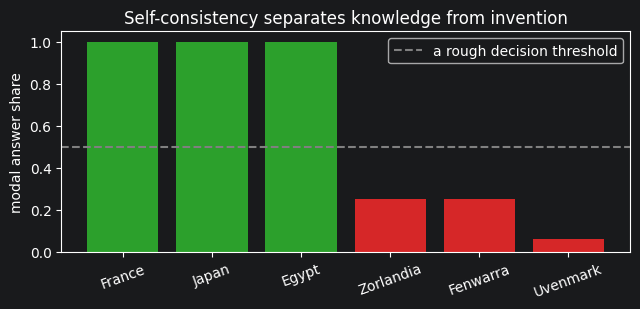

Green bars are real places, red are invented. The gap is the detector.


In [22]:
N_SAMPLES = 16                                                         # samples per question
print(f"{'':10} {'place':<11} {'modal share':>12} {'greedy answer':>16}   most common answers")
results = {}                                                           # keep the shares for the plot
for label, names in [("REAL", REAL), ("INVENTED", FAKE)]:
    for nm in names:
        answers = [first_word(a) for a in ask_capital(nm, n=N_SAMPLES)]     # sample many times
        counts = Counter(answers)                                          # cluster by exact match
        share = counts.most_common(1)[0][1] / N_SAMPLES                    # how often the winner won
        results[nm] = (label, share)
        greedy = first_word(ask_capital(nm, greedy=True)[0])                # what greedy says
        print(f"{label:>10} {nm:<11} {share:>12.2f} {greedy:>16}   {counts.most_common(3)}")

plt.figure(figsize=(6.5, 3.2))
names = list(results.keys())                                           # x axis order
colours = ["tab:green" if results[n][0] == "REAL" else "tab:red" for n in names]   # green = real
plt.bar(names, [results[n][1] for n in names], color=colours)          # bar height = modal share
plt.axhline(0.5, ls="--", c="grey", label="a rough decision threshold")
plt.ylabel("modal answer share"); plt.ylim(0, 1.05); plt.legend()
plt.title("Self-consistency separates knowledge from invention"); plt.xticks(rotation=20)
plt.tight_layout(); plt.show()
print("Green bars are real places, red are invented. The gap is the detector.")

In [23]:
# Does greedy decoding fix hallucination? It does not, and this is the cell that proves it.
print("greedy (temperature 0) answers for the invented places, five runs each:\n")
for nm in FAKE:
    outs = [first_word(ask_capital(nm, greedy=True)[0]) for _ in range(5)]   # deterministic decoding
    print(f"  {nm:<11} {outs}")
print("\nGreedy decoding removes the VARIATION, not the fabrication. You get one confident wrong")
print("answer instead of sixteen different ones, which is worse for detection: the very signal we")
print("just used to catch the problem is what temperature 0 throws away.")

greedy (temperature 0) answers for the invented places, five runs each:

  Zorlandia   ['zorlandia', 'zorlandia', 'zorlandia', 'zorlandia', 'zorlandia']
  Fenwarra    ['rio', 'rio', 'rio', 'rio', 'rio']
  Uvenmark    ['umea', 'umea', 'umea', 'umea', 'umea']

Greedy decoding removes the VARIATION, not the fabrication. You get one confident wrong
answer instead of sixteen different ones, which is worse for detection: the very signal we
just used to catch the problem is what temperature 0 throws away.


## Section 5. Training a language model: the mechanics

Pretraining a serious model is not something we can do in a tutorial, but the *loop* is small and
worth reading closely, because every line in it exists for a reason.

### Data curation, in the order it actually happens
1. **Collect**, from web crawls, books, code, and so on.
2. **Deduplicate**. Repeated documents get memorised and waste compute.
3. **Filter** for quality and language, and strip boilerplate.
4. **Remove personal data and unsafe content**, as far as is practical.
5. **Decontaminate** against your evaluation benchmarks, or your scores are meaningless.
6. **Mix** the sources deliberately. The mixture is a design choice, not an accident.

### How much data does a model need
The Chinchilla result is the usual reference point: for a compute-optimal model, tokens should scale
roughly **20 times** the parameter count.

| Parameters | Roughly compute-optimal tokens |
|---|---|
| 100 M | 2 B |
| 1 B | 20 B |
| 7 B | 140 B |
| 70 B | 1.4 T |

Models are often trained well past this point, because inference cost is paid forever while training
cost is paid once, and a smaller model trained longer is cheaper to serve.

### The training loop, annotated

Read this cell rather than running it. It is the real thing, with the pieces named. The next cell runs
a cut-down version that actually trains.

In [24]:
# ---- Reference training loop. Do not run this cell, it is here to be read. ----
#
# for step, batch in enumerate(loader):                     # stream batches, never load all data
#     with torch.autocast(device_type="cuda", dtype=torch.bfloat16):   # mixed precision: less memory,
#         out = model(input_ids=batch["ids"], labels=batch["ids"])     # faster matmuls, same result
#         loss = out.loss / ACCUM_STEPS                     # scale down because we accumulate
#
#     loss.backward()                                       # gradients ADD to whatever is there
#
#     if (step + 1) % ACCUM_STEPS == 0:                     # gradient accumulation: simulate a big
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)   # batch on small hardware, then
#         optimizer.step()                                  # clip to survive the occasional bad batch
#         scheduler.step()                                  # warm up, then decay the learning rate
#         optimizer.zero_grad(set_to_none=True)             # set_to_none frees the gradient buffers
#
#     if (step + 1) % EVAL_EVERY == 0:                      # validate on held-out data
#         val = evaluate(model, val_loader)                 # never checkpoint on training loss
#         if val < best_val:                                # keep the best model, not the last one
#             best_val = val
#             torch.save({"model": model.state_dict(),      # save the optimiser state too, or you
#                         "optim": optimizer.state_dict(),  # cannot resume a run properly
#                         "step": step}, "checkpoint.pt")

### Now train one for real

We will train a genuinely tiny model, about 0.1 M parameters, on the field reports from Section 1,
using the tokenizer we trained there. This takes a few seconds.

Be clear about what to expect. Our corpus is generated from a handful of templates, so a small model
can learn those templates well and will produce fluent, grammatical output. That is not the same as
being a good language model: it has learned the shape of our sentences and has nothing whatsoever to
say. Watch the loss curve, not the prose.

In [25]:
from transformers import GPT2Config, GPT2LMHeadModel, PreTrainedTokenizerFast   # a small GPT-2 shell

tk_fast = PreTrainedTokenizerFast(tokenizer_object=trained[1024],       # reuse the Section 1 tokenizer
                                  unk_token="<unk>", pad_token="<pad>", eos_token="<eos>")
V = tk_fast.vocab_size                                                  # vocabulary size for the model
stream = []                                                             # one long stream of token ids
for report in corpus:                                                   # concatenate the whole corpus
    stream += tk_fast(report)["input_ids"] + [tk_fast.eos_token_id]     # separate reports with <eos>
data = torch.tensor(stream)                                             # as one tensor
split = int(0.9 * len(data))                                            # 90/10 train/validation
train_data, val_data = data[:split], data[split:]                       # never validate on train data
SEQ = 64                                                                # context length
print(f"vocabulary {V} | total tokens {len(data):,} | train {len(train_data):,} val {len(val_data):,}")

def get_batch(src, batch_size=16):
    # Cut batch_size random windows of length SEQ out of the token stream.
    starts = torch.randint(0, len(src) - SEQ - 1, (batch_size,))        # random start positions
    x = torch.stack([src[s:s + SEQ] for s in starts]).to(device)        # the windows themselves
    return x, x.clone()                                                 # labels are the inputs, shifted
                                                                        # internally by the model
cfg = GPT2Config(vocab_size=V, n_positions=SEQ, n_embd=64, n_layer=2, n_head=4,
                 bos_token_id=tk_fast.eos_token_id, eos_token_id=tk_fast.eos_token_id)
tiny = GPT2LMHeadModel(cfg).to(device)                                  # a fresh, untrained model
print(f"parameters: {sum(p.numel() for p in tiny.parameters())/1e6:.2f}M")

vocabulary 1024 | total tokens 275,388 | train 247,849 val 27,539
parameters: 0.17M


trained 300 iterations in 6.9s


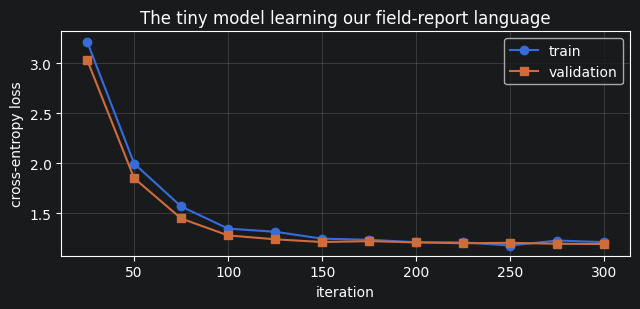

final train 1.208 | final validation 1.189
Train and validation fall together, so this model is too small to overfit 6000 reports. If
validation had turned upward while train kept falling, that gap would be overfitting.


In [26]:
opt = torch.optim.AdamW(tiny.parameters(), lr=3e-3)                     # the optimiser
sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=TRAIN_ITERS)   # decay the learning rate
hist = []                                                               # (iteration, train, val) rows
t0 = time.time()
tiny.train()                                                            # training mode
for it in range(TRAIN_ITERS):
    x, y = get_batch(train_data)                                        # one batch
    loss = tiny(input_ids=x, labels=y).loss                             # forward pass and loss
    loss.backward()                                                     # gradients
    torch.nn.utils.clip_grad_norm_(tiny.parameters(), 1.0)              # clip, as in the reference loop
    opt.step(); sched.step(); opt.zero_grad(set_to_none=True)           # update, decay, clear
    if (it + 1) % 25 == 0:                                              # evaluate periodically
        tiny.eval()                                                     # evaluation mode
        with torch.no_grad():                                           # no gradients for validation
            vl = float(np.mean([tiny(input_ids=(b := get_batch(val_data))[0], labels=b[1]).loss.item()
                                for _ in range(5)]))                    # average a few val batches
        tiny.train()                                                    # back to training mode
        hist.append((it + 1, loss.item(), vl))                          # record the pair
print(f"trained {TRAIN_ITERS} iterations in {time.time()-t0:.1f}s")

plt.figure(figsize=(6.5, 3.2))
plt.plot([h[0] for h in hist], [h[1] for h in hist], "o-", label="train")     # training loss
plt.plot([h[0] for h in hist], [h[2] for h in hist], "s-", label="validation")  # validation loss
plt.xlabel("iteration"); plt.ylabel("cross-entropy loss"); plt.legend(); plt.grid(True, alpha=0.3)
plt.title("The tiny model learning our field-report language"); plt.tight_layout(); plt.show()
print(f"final train {hist[-1][1]:.3f} | final validation {hist[-1][2]:.3f}")
print("Train and validation fall together, so this model is too small to overfit 6000 reports. If")
print("validation had turned upward while train kept falling, that gap would be overfitting.")

In [27]:
tiny.eval()                                                             # generate from our own model
seed_text = "in 1975 the surveyor"                                      # a prompt in the corpus style
enc = tk_fast(seed_text, return_tensors="pt").to(device)                # encode with OUR tokenizer
with torch.no_grad():
    out = tiny.generate(**enc, max_new_tokens=45,
                        do_sample=True, temperature=0.8, top_p=0.95,     # the Section 2 settings
                        pad_token_id=tk_fast.pad_token_id)
print("our tiny model says:\n")
print(tk_fast.decode(out[0], skip_special_tokens=True))
print("\nFluent, grammatical, and completely empty. It learned our templates. That is what a language")
print("model does when its training data has no information in it beyond its own form.")
print("\nOne reading note: you will see gaps inside some words, like a year printed as '197 5' or a")
print("place name as 'Bright mere'. Those are the subword pieces the model emitted, shown separately")
print("because our whitespace tokenizer records no information about the original spacing. Real")
print("tokenizers (including the one on the models we downloaded) store that, which is why their")
print("output reassembles cleanly.")

our tiny model says:

in 197 5 the surveyor photographed the windy wetland the steep island the the the the the steep desert the the the the the the the the the the the millet was already tall . the the the the the the the the the the the the the the the

Fluent, grammatical, and completely empty. It learned our templates. That is what a language
model does when its training data has no information in it beyond its own form.

One reading note: you will see gaps inside some words, like a year printed as '197 5' or a
place name as 'Bright mere'. Those are the subword pieces the model emitted, shown separately
because our whitespace tokenizer records no information about the original spacing. Real
tokenizers (including the one on the models we downloaded) store that, which is why their
output reassembles cleanly.


### How trained models get evaluated

Loss is what you optimise, not what you care about. Public models are compared on benchmark suites,
each targeting a different capability.

| Benchmark | What it tests |
|---|---|
| **ARC** | grade-school science questions, multiple choice |
| **HellaSwag** | commonsense sentence completion |
| **MMLU** | 57 subjects of academic knowledge, multiple choice |
| **TruthfulQA** | resisting common misconceptions |
| **GSM8K** | grade-school maths word problems, multi-step |
| **HumanEval** | writing Python functions that pass unit tests |
| **MT-Bench** | multi-turn conversation quality, graded by a stronger model |

**TruthfulQA** is the one that connects back to Section 4: it exists precisely because fluency and
truthfulness came apart, and no amount of loss reduction fixed it on its own.

## Section 6. Alignment: making a model prefer some answers over others

A pretrained model imitates its training data. That is not the same as being useful, honest, or
pleasant to interact with. **Alignment** is the stage that closes that gap, and it works from
**human preferences**: pairs of responses to the same prompt, where a person marked one as better.

### The RLHF objective
The standard formulation maximises reward while staying close to the original model:

$$\max_{\pi} \; \mathbb{E}_{x \sim D,\, y \sim \pi(\cdot|x)} \big[ r(x, y) \big] \; - \; \beta \, \mathrm{KL}\!\left( \pi(y|x) \,\|\, \pi_{\text{ref}}(y|x) \right)$$

The reward term pulls toward what people liked. The KL term is a leash: without it the model drifts
into degenerate text that happens to score well. `beta` sets how much drift you tolerate.

This objective has a **closed-form optimum**:

$$\pi^{*}(y|x) \;=\; \frac{1}{Z(x)} \, \pi_{\text{ref}}(y|x) \, \exp\!\left( \frac{r(x,y)}{\beta} \right)$$

Read that as Bayes' rule: the reference model is the prior, the exponentiated reward is the
likelihood, and the aligned model is the posterior. Alignment is reweighting a distribution you
already have, not building a new one.

### Where PPO fits, and why we are not using it
The classic recipe (RLHF) trains a reward model on preferences, then optimises the objective above
with **PPO**, a reinforcement learning algorithm. It works, and it is what made ChatGPT-style models
possible, but for a tutorial it is a poor fit: it needs a policy, a frozen reference, a value head and
a reward model in memory at once, plus a generation rollout at every step.

The route we take instead is **DPO**, which reaches the same optimum without any reinforcement
learning at all. PPO's mechanics (the clipped surrogate objective, advantages, the value function)
belong with policy-gradient methods and are covered properly in a reinforcement learning tutorial,
where you meet the plain policy gradient first.

### Step 1: how preferences become a loss
The **Bradley-Terry** model says the probability that response `w` beats response `l` is a sigmoid of
their score difference. Maximising the likelihood of the observed human choices gives:

$$\mathcal{L} = -\log \sigma\big( s(x, y_w) - s(x, y_l) \big)$$

Only the **difference** appears, so absolute scores are unidentifiable. That is worth internalising
before the DPO derivation, where the same cancellation does the real work.

 winner score  loser score   margin     loss   reading
          2.0          1.0      1.0   0.3133   preferred wins by 1, modest loss
          5.0          1.0      4.0   0.0181   preferred wins clearly, low loss
          1.0          1.0      0.0   0.6931   no preference expressed, loss = log 2
          1.0          3.0     -2.0   2.1269   model has it BACKWARDS, large loss
         12.0          1.0     11.0   0.0000   very confident, loss near zero


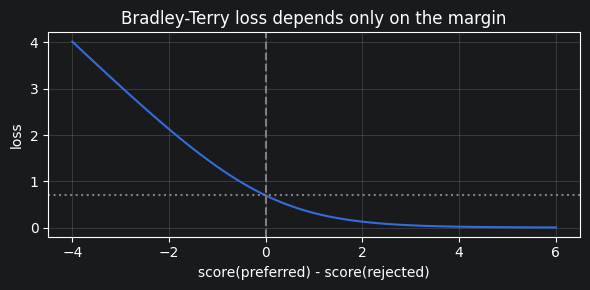

At margin 0 the loss is log 2 = 0.6931, which is where an untrained model starts.


In [28]:
def bradley_terry_loss(score_win, score_lose):
    # The preference loss: minimised by making the preferred score higher than the rejected one.
    return -F.logsigmoid(score_win - score_lose)                        # log sigmoid of the difference

print(f"{'winner score':>13} {'loser score':>12} {'margin':>8} {'loss':>8}   reading")
for sw, sl, note in [(2.0, 1.0, "preferred wins by 1, modest loss"),
                     (5.0, 1.0, "preferred wins clearly, low loss"),
                     (1.0, 1.0, "no preference expressed, loss = log 2"),
                     (1.0, 3.0, "model has it BACKWARDS, large loss"),
                     (12.0, 1.0, "very confident, loss near zero")]:
    w, l = torch.tensor(sw), torch.tensor(sl)                           # the loss wants tensors
    print(f"{sw:>13.1f} {sl:>12.1f} {sw-sl:>8.1f} {bradley_terry_loss(w, l).item():>8.4f}   {note}")

margins = torch.linspace(-4, 6, 100)                                    # a range of score differences
plt.figure(figsize=(6, 3))
plt.plot(margins, -F.logsigmoid(margins))                               # the loss as a function of it
plt.axvline(0, ls="--", c="grey")                                       # margin 0 = no preference
plt.axhline(math.log(2), ls=":", c="grey")                              # and the loss there is log 2
plt.xlabel("score(preferred) - score(rejected)"); plt.ylabel("loss")
plt.title("Bradley-Terry loss depends only on the margin"); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()
print(f"At margin 0 the loss is log 2 = {math.log(2):.4f}, which is where an untrained model starts.")

### Step 2: DPO, and the substitution that removes the reward model

Rearranging the closed-form optimum for `r` gives the reward implied by any policy:

$$r(x, y) \;=\; \beta \, \log \frac{\pi(y|x)}{\pi_{\text{ref}}(y|x)} \; + \; \beta \log Z(x)$$

Now put that into the Bradley-Terry loss. Both responses share the same prompt `x`, so `beta log Z(x)`
appears in both scores and **cancels in the difference**. The intractable normaliser disappears, and
with it the need for a separate reward model:

$$\mathcal{L}_{\text{DPO}} = -\log \sigma\!\left( \beta \left[ \log \frac{\pi(y_w|x)}{\pi_{\text{ref}}(y_w|x)} - \log \frac{\pi(y_l|x)}{\pi_{\text{ref}}(y_l|x)} \right] \right)$$

What is left is a supervised loss on four log-probabilities. No reward model, no rollouts, no
reinforcement learning. Two models in memory, one of them frozen.

The quantity inside the brackets is the **implicit reward margin**. It starts near zero and should
grow as training proceeds. In Part 2 you will complete this loss and watch that happen.

In [29]:
def dpo_loss(pi_win, pi_lose, ref_win, ref_lose, beta=0.1):
    # All four arguments are SUMMED log-probabilities of a full response, not per-token averages.
    pi_ratio_win  = pi_win  - ref_win                                   # log pi(y_w) - log ref(y_w)
    pi_ratio_lose = pi_lose - ref_lose                                  # log pi(y_l) - log ref(y_l)
    margin = pi_ratio_win - pi_ratio_lose                               # the implicit reward margin
    return -F.logsigmoid(beta * margin), margin                         # loss, and the margin to log

# Three hand-made cases, so the numbers are checkable by eye.
print(f"{'case':>34} {'margin':>8} {'loss':>8}")
# Columns are (policy chosen, policy rejected, reference chosen, reference rejected).
for note, a, b, c, d in [
    ("untrained: policy equals reference", -20.0, -30.0, -20.0, -30.0),
    ("policy prefers the good response",   -18.0, -32.0, -20.0, -30.0),
    ("policy prefers the BAD response",    -22.0, -28.0, -20.0, -30.0)]:
    loss, margin = dpo_loss(*(torch.tensor(v) for v in (a, b, c, d)))    # same order as above
    print(f"{note:>34} {margin.item():>8.1f} {loss.item():>8.4f}")
print("\nThe first row is the starting point of any DPO run: the policy IS the reference, so the")
print("margin is exactly 0 and the loss is exactly log 2. If your Part 2 run does not start there,")
print("something is wrong with your log-probability computation.")

                              case   margin     loss
untrained: policy equals reference      0.0   0.6931
  policy prefers the good response      4.0   0.5130
   policy prefers the BAD response     -4.0   0.9130

The first row is the starting point of any DPO run: the policy IS the reference, so the
margin is exactly 0 and the loss is exactly log 2. If your Part 2 run does not start there,
something is wrong with your log-probability computation.


## Section 7. Recap

- **Tokenization.** Text becomes token ids by subword merging. You ran BPE by hand, trained real
  tokenizers at five vocabulary sizes, measured the compression against sequence-length trade-off, and
  saw what a mismatched tokenizer does.
- **Decoding.** You reimplemented the generation loop and saw greedy, temperature, top-k, top-p and
  beam search as transforms of one next-token distribution, with entropy and diversity measured rather
  than described.
- **Architecture.** Every LLM you touched is a **causal decoder**, proven on a real attention matrix
  rather than asserted, and it differs from Tutorial 7's encoder in exactly one mechanism: the mask.
  You also saw where the two downloaded models diverge from the original 2017 design and from each
  other: RMSNorm, RoPE, and grouped-query attention are not decoration, they show up as real numbers
  in `model.config`.
- **Hallucination.** Fluency is not knowledge. Token probabilities do not reveal fabrication, but
  self-consistency across samples does, and greedy decoding hides the signal instead of fixing the
  problem.
- **Training.** You read a real training loop, then trained a 0.1 M-parameter model that learned our
  templates perfectly and had nothing to say, which is the cleanest possible illustration of why data
  matters more than the loop.
- **Alignment.** The RLHF objective is reward minus a KL leash; its optimum is Bayes' rule. The
  Bradley-Terry loss turns preferences into gradients, and the DPO substitution cancels the
  normaliser, removing the reward model and the reinforcement learning entirely.

The honest limits: these are 68 M and 135 M parameter models. They hallucinate constantly, their
knowledge is thin, and behaviour that needs scale (in-context learning, chain-of-thought reasoning)
barely appears. Every mechanism you touched is the one used at production scale. Only the scale is
missing.

---
# Part 2 - Unguided exercise (about 1 to 1.5 hours)

Work through this on your own. There are hints but **no worked solution**. Everything from Part 1 is
available once you have run it: `lm_ins`, `tok_ins`, `dpo_loss`, `transform_logits`, `device`, `SEED`.

## Task 1, find and fix a bug in a decoding function (about 15 min)

The function below is supposed to be top-p (nucleus) sampling. It is not. It runs without error and
returns plausible-looking text, which is what makes this worth your time.

Read it against the correct version in Section 2, work out what it actually does, and fix it. Then
demonstrate the difference: for a fixed context and `p = 0.9`, report how many tokens each version
keeps, and show that only one of them has the defining property of nucleus sampling, namely that the
kept tokens are the most probable ones and their probabilities sum to at least `p`.

```python
def broken_top_p(logits, p=0.9):
    probs = torch.softmax(logits, dim=-1)          # probabilities, in vocabulary order
    threshold = torch.rand(1).item()               # one uniform draw
    cumulative = probs.cumsum(dim=-1)              # running total, in vocabulary order
    cut = (cumulative < threshold).sum().item()    # first index past the threshold
    keep = torch.arange(cut + 1)                   # keep everything up to there
    out = torch.full_like(logits, float("-inf"))
    out[keep] = logits[keep]
    return torch.softmax(out, dim=-1)
```

Write two or three sentences naming the sampling scheme this actually implements, because it is a real
scheme, just not the one advertised.

## Task 2, build a preference dataset (about 15 min)

Your alignment axis is **concise against verbose**. Build 40 triplets of
`(prompt, chosen, rejected)`, where the prompt asks the model to describe a landform in one sentence.

- `chosen`: a short, direct answer that you write yourself, one clause, no preamble.
- `rejected`: **the model's own answer**, sampled from `lm_ins` at `temperature=0.9`. Use 8 landforms
  and sample 5 different responses for each, which gives you your 40 pairs.

That second point is the one that matters, and it is easy to get wrong. It is tempting to write the
rejected responses by hand too, for instance by pasting filler in front of the good answer. That
trains fine and the margin climbs happily, but it changes nothing you can observe, because the model
never generates that filler in the first place. DPO adjusts the likelihood of responses *relative to
each other*, so the rejected side has to look like what the model actually does, or you are pushing
away from text that was never in your way. Sampling the rejected side from the model itself is what
real DPO pipelines do, and it is why this task specifies it.

Hold back **10 landforms that never appear in training**. You need them in Task 4.

This axis is chosen deliberately: it is verifiable by counting tokens, so you can measure success
without a human judge or a stronger model.

## Task 3, complete the DPO training step (about 25 min)

1. Write `sequence_logprob(model, prompt, response)` returning the **summed** log-probability of the
   response tokens only, with the prompt tokens masked out of the sum.
2. Load a **second frozen copy** of the model as the reference, and **cache its log-probabilities for
   all 40 pairs once, before training**. The reference never changes, so recomputing it every step
   doubles your work for nothing. Delete the reference model afterwards to free the memory.
3. Train with `dpo_loss` from Section 6. Freeze most of the network and train only the last two or
   three transformer blocks; the full model is unnecessary here and much slower.
4. Log the loss and the mean implicit reward margin. The loss must start at `log 2 = 0.693` and the
   margin at 0. If it does not, your log-probabilities are wrong, so fix that before training further.

## Task 4, evaluate whether it worked (about 20 min)

On your 10 held-out prompts, generate **greedily** from the aligned model and from the original, and
report:
- the **win rate**: the fraction of held-out prompts where the aligned answer is shorter in tokens
  than the original's,
- mean response length in tokens, before and after,
- two or three example pairs, printed side by side.

Generate the "before" answers **before you start training**, or copy the original weights first.
Fine-tuning modifies `lm_ins` in place, so once you have trained there is no un-aligned model left to
compare against.

A win rate around 0.6 and a length drop of roughly 10 to 20 per cent is a realistic result here. If
you get 1.0, check you are really comparing against the untrained model.

## Task 5, written (about 10 min)

Name **two failure modes of DPO that your win rate would not detect**, and say briefly how you would
test for each. Be specific to this setup, not generic. Some starting points: what happens to answers
on topics absent from your 40 pairs, what stops the model learning "shorter is always better" to the
point of uselessness, what the KL leash is doing while you optimise a proxy, and whether a shorter
answer is still a *correct* answer (your win rate never checks).

## Stretch (optional), alignment with no training at all

The closed-form optimum says the aligned model is the reference reweighted by `exp(r/beta)`. You can
approximate that by sampling instead of training: draw 16 candidate responses, score each with a
reward proxy (negative token count, for the concise axis), weight by `exp(score/beta)`, and resample.
Compare the result against your DPO model on the same 10 prompts.

This is worth doing even if your DPO run works, because it separates two things that are easy to
conflate: the objective, and the method used to reach it.

### Hints
- The loss must start at exactly `log 2`. This is the single most useful check in the whole exercise.
- Mask the prompt with `-100` labels and sum only where the mask is true. Averaging instead of summing
  changes the objective, because it removes the length signal you are trying to train on.
- Compute log-probabilities in `float32` (`logits.float()`) even on a half-precision model. Summed
  log-probabilities over long responses lose precision quickly otherwise.
- Freeze parameters with `p.requires_grad = False`, and pass only the trainable ones to the optimiser.
- `beta = 0.1`, a learning rate around `1e-4`, batch size 4, and 3 passes over the 40 pairs is a
  combination that works. On Apple MPS or a GPU that is well under a minute; on CPU allow a few
  minutes.
- Sampling the 40 rejected responses takes about 40 seconds. Do it once and keep them.
- A rising margin proves the loss is being minimised. It does not prove the model's behaviour changed.
  Those are different claims, and Task 4 tests the second one.

### What to submit
Your filled-in cells (runnable top to bottom), the fixed `top_p` with its demonstration, your win-rate
table, and the Task 5 written answer.

### Task 1 (your code below)

In [30]:
# TODO Task 1: fix broken_top_p, and demonstrate the difference against the correct version.

### Task 2 (your code below)

In [31]:
# TODO Task 2: build 40 (prompt, chosen, rejected) triplets, plus 10 held-out prompts.

### Task 3 (your code below)

In [32]:
# TODO Task 3: sequence_logprob, cached reference log-probs, and the DPO training loop.

### Task 4 (your code below)

In [33]:
# TODO Task 4: win rate and mean length, aligned against original, on the held-out prompts.

### Task 5 (your written answer below)

*Write your answer to Task 5 here: two DPO failure modes the win rate would not detect, and how you would test for each.*

### Stretch (optional, your code below)

In [34]:
# TODO (optional): best-of-16 reweighting by exp(reward/beta), compared against your DPO model.